Backward Facing Step Flow (BFS) DEMO code

This notebook demonstrates solving steady-state Backward Facing Step Flow (BFS) using DeepFlow. The BFS flow is a common benchmark problem in fluid dynamics, where the flow separates and reattaches after encountering a step.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the six-boundary backward-facing-step channel. This defines the area for simulation.

In [2]:
rectangle = df.geometry.polygon(
    [0, 0.4], [0, 1], [5, 1], [5, 0], [1, 0], [1, 0.4]
)

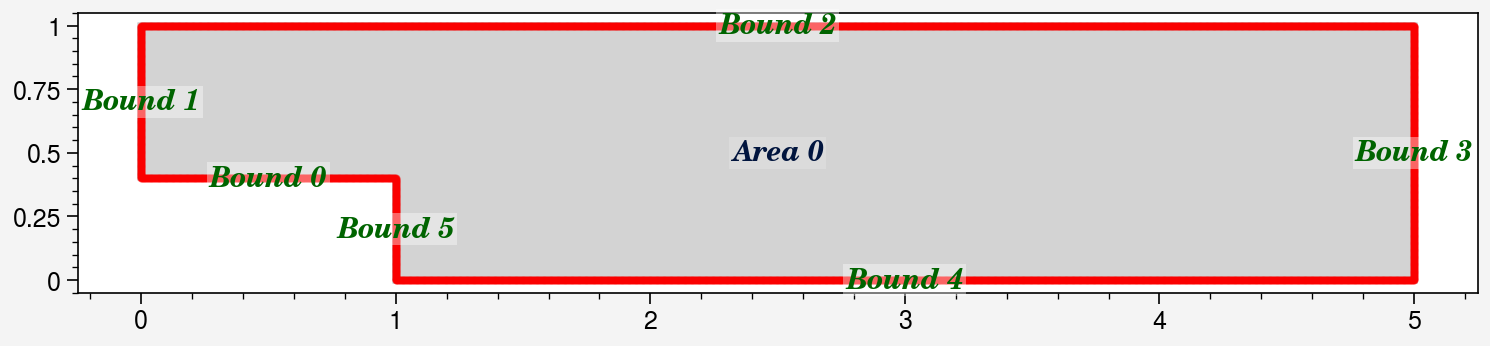

In [3]:
domain = df.domain(rectangle)
domain.show_setup()

## 2. Define Physics
Define the Navier-Stokes equations for fluid flow and apply boundary conditions (e.g., no-slip walls, inlet velocity).

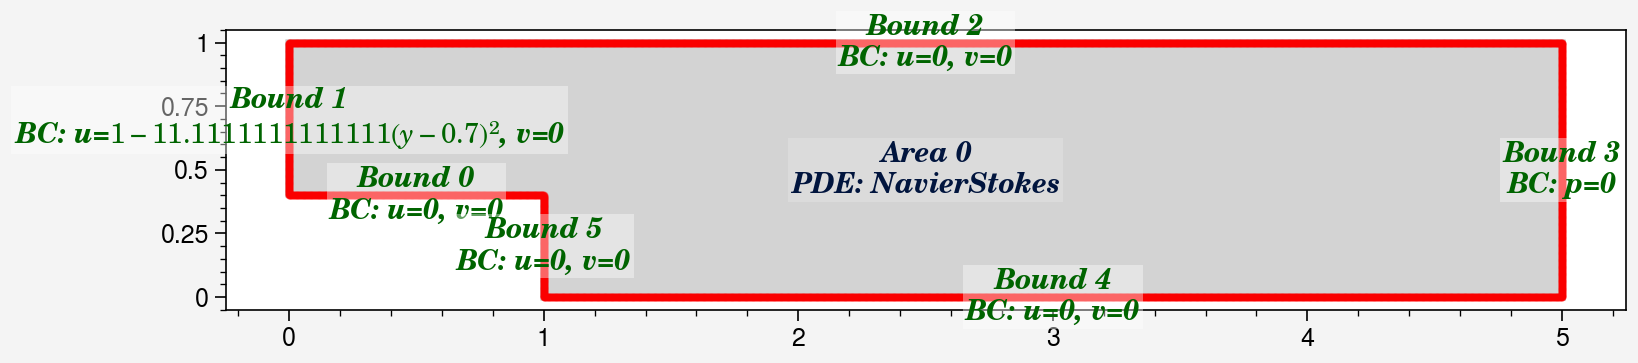

In [4]:
domain.bound_list[0].define_bc({'u': 0,'v': 0})
domain.bound_list[1].define_bc({'u': df.parabolic_func('y', 0.6, 1, 0.7),'v': 0})
domain.bound_list[2].define_bc({'u': 0,'v': 0})
domain.bound_list[3].define_bc({'p': 0})
domain.bound_list[4].define_bc({'u': 0,'v': 0})
domain.bound_list[5].define_bc({'u': 0,'v': 0})
domain.area_list[0].define_pde(df.NavierStokes(U=0.0001, L=1, mu=0.001, rho=1000))
domain.show_setup()


Sample initial points for training.

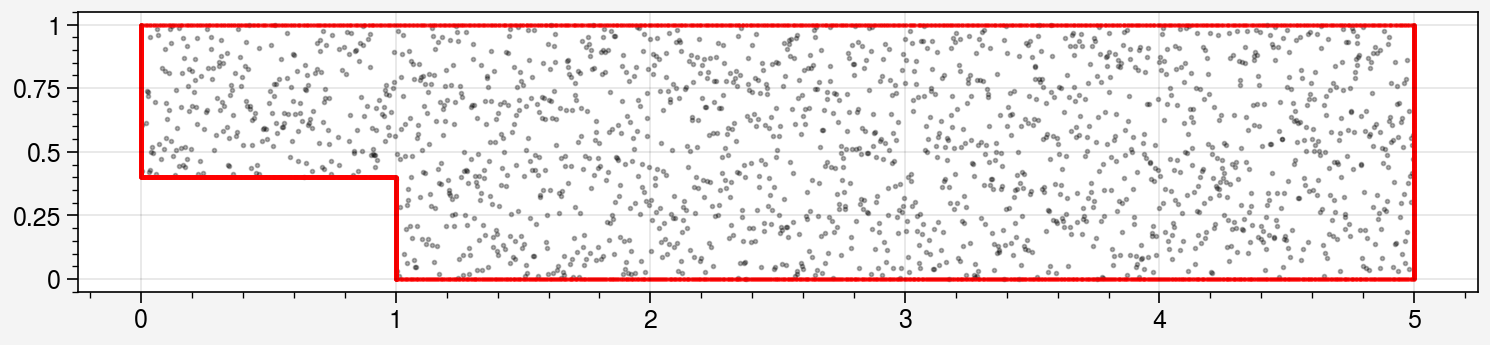

In [5]:
domain.sampling_lhs(bound_sampling_res=[1000, 1000, 1000, 1000, 1000, 1000], area_sampling_res=[2000])
domain.show_coordinates(display_physics=False)

## 3. Train the PINN model

Define how collocation points are sampled during training.

In [6]:
def do_in_adam(epoch, model):
    if epoch % 100 == 0 and epoch > 0:
        domain.sampling_R3(bound_sampling_res=[1000, 1000, 1000, 1000, 1], area_sampling_res=[2000])
        print(domain)

Train the model using Adam for initial training (faster convergence).

In [7]:
model0 = df.PINN(width=50, length=5, input_vars=['x','y'], output_vars=['u','v','p'])

# Train the model
model1, model1best = model0.train_adam(
    learning_rate=0.001,
    epochs=2000,
    calc_loss=df.calc_loss_simple(domain),
    threshold_loss=0.005,
    do_between_epochs=do_in_adam)

Epoch: 1, total_loss: 0.78462, bc_loss: 0.78430, pde_loss: 0.00032


number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1855']


Epoch: 200, total_loss: 0.32137, bc_loss: 0.28598, pde_loss: 0.03539
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1882']


number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1892']


Epoch: 400, total_loss: 0.03698, bc_loss: 0.01884, pde_loss: 0.01814
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1891']


...

Epoch: 1600, total_loss: 0.01036, bc_loss: 0.00521, pde_loss: 0.00515
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1933']


number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1928']


Epoch: 1800, total_loss: 0.00856, bc_loss: 0.00441, pde_loss: 0.00415
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1924']


number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1925']


Epoch: 2000, total_loss: 0.00931, bc_loss: 0.00455, pde_loss: 0.00476
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 1', '5: 1000']
number of area : ['0: 1930']


Refine the model using LBFGS for higher precision.

In [8]:
# Train the model
model2, model2best = model1best.train_lbfgs(
    calc_loss=df.calc_loss_simple(domain),
    epochs=350,
    threshold_loss=0.0001)

Epoch: 2050, total_loss: 0.00146, bc_loss: 0.00066, pde_loss: 0.00080


Epoch: 2100, total_loss: 0.00019, bc_loss: 0.00006, pde_loss: 0.00013


Stop: Loss 0.00010 < Threshold 0.0001
Epoch: 2117, total_loss: 0.00010, bc_loss: 0.00003, pde_loss: 0.00007


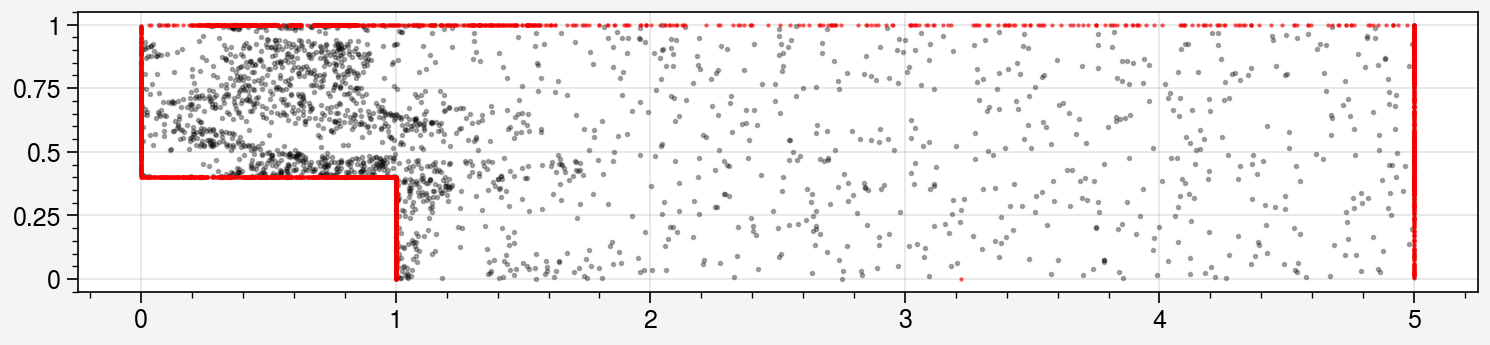

In [9]:
domain.show_coordinates()

Save or Load the model for later use

In [10]:
model2.save_as_pickle("model.pkl")
model2 = df.load_from_pickle("model.pkl")

## 4. Visualization

### 4.1 Visualize area

In [11]:
df.Visualizer.refwidth_default = 7

In [12]:
# Create object for evaluation
area_eval = domain.area_list[0].evaluate(model2)
# Sampling uniform points
area_eval.sampling_area([300, 60])
# Show available data's key
print(area_eval)

Available data keys: ('u', 'v', 'p', 'pde_residual', 'x', 'y', 'u_x', 'u_y', 'v_x', 'v_y', 'p_x', 'p_y', 'continuity_residual', 'x_momentum_residual', 'y_momentum_residual', 'total_loss', 'bc_loss', 'pde_loss')


In [13]:
area_eval['v_mag'] = (area_eval['u']**2 + area_eval['v']**2)**0.5

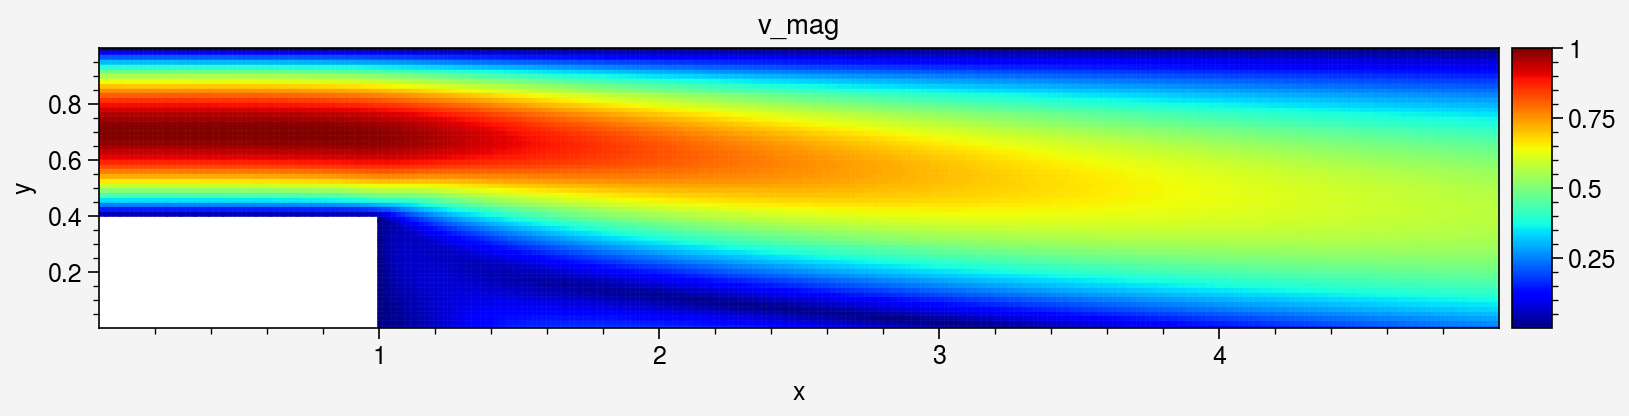

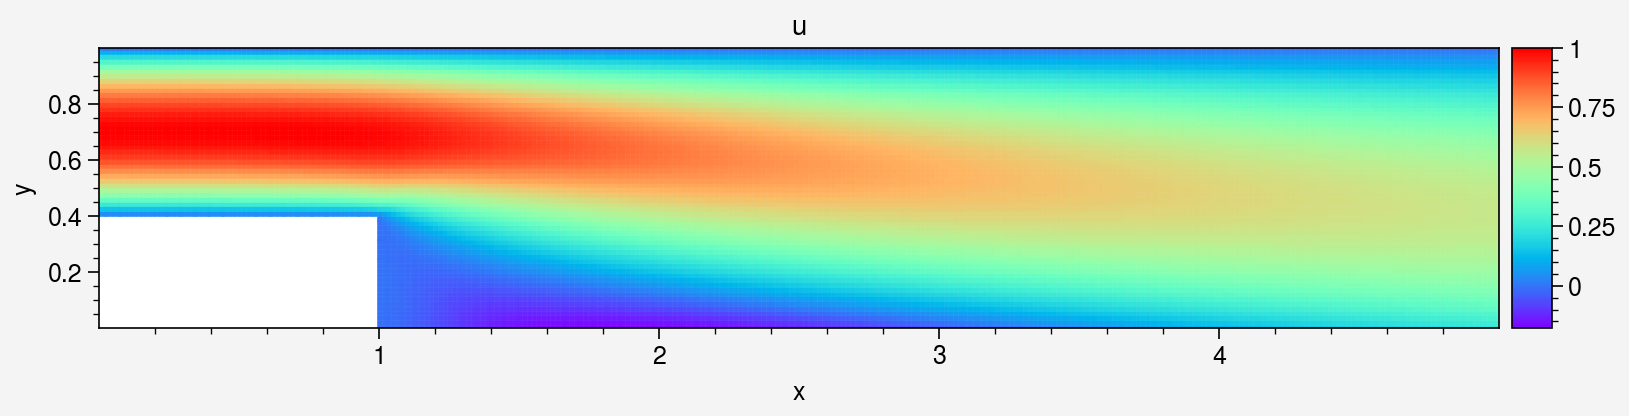

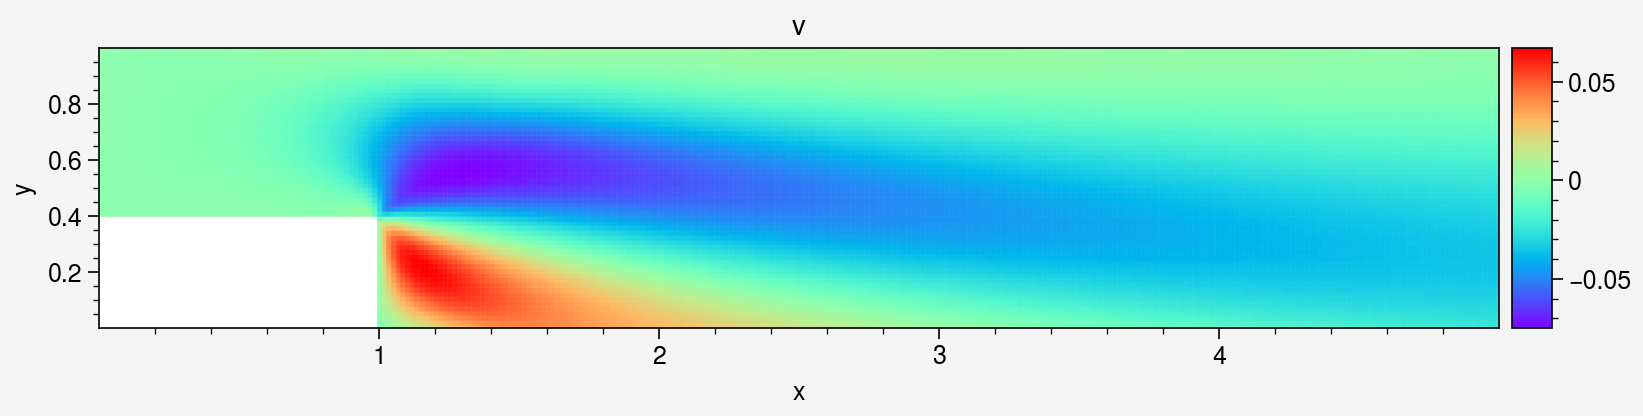

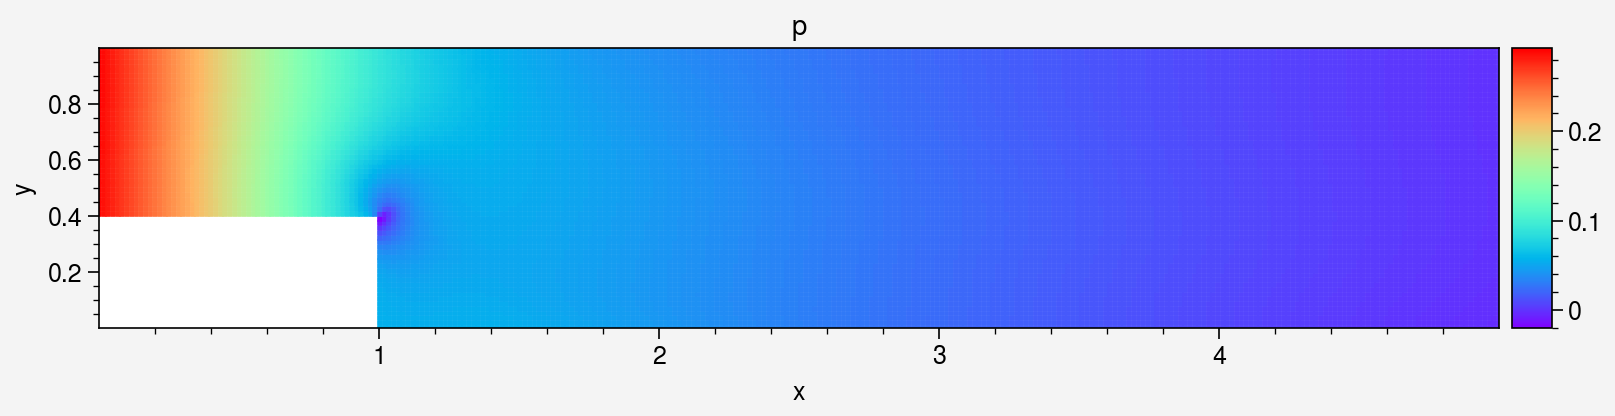

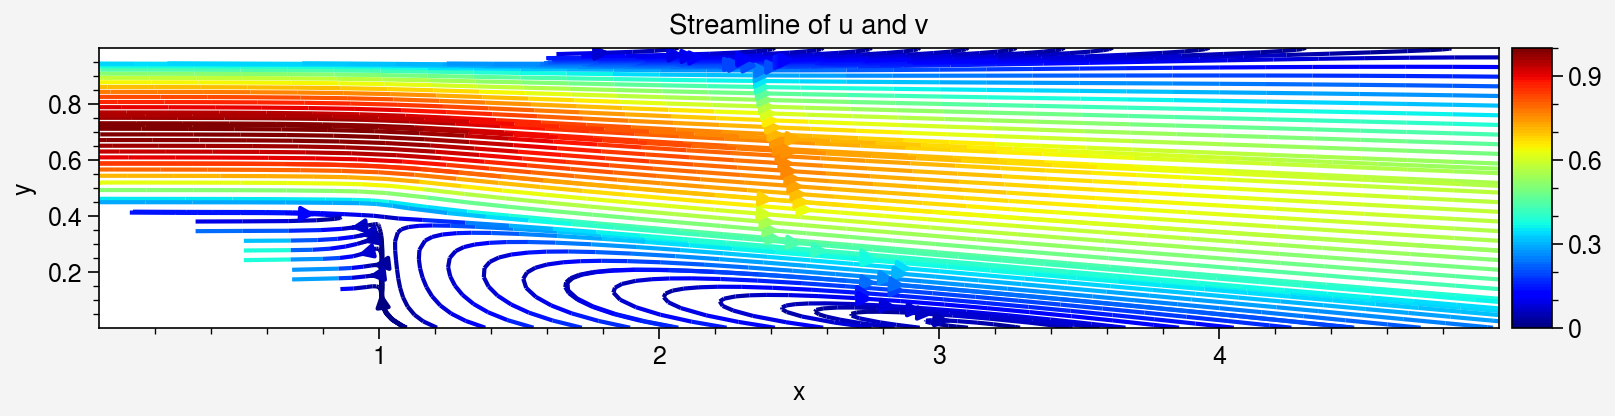

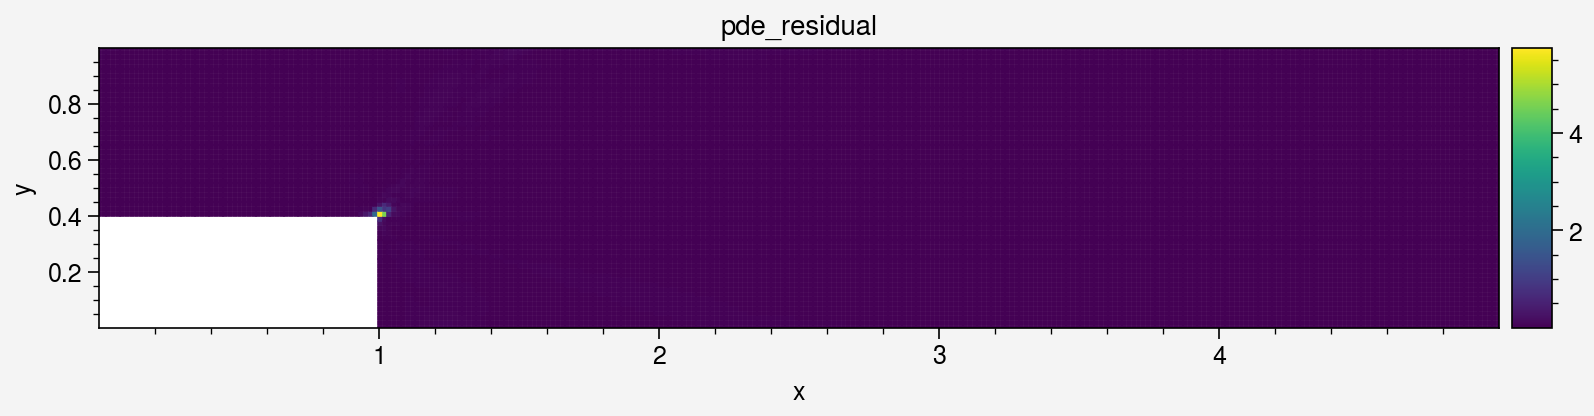

In [14]:
_ = area_eval.plot_color('v_mag', s=2, cmap='jet').savefig("colorplot_v_mag.png")
_ = area_eval.plot_color('u', s=2, cmap='rainbow')
_ = area_eval.plot_color('v', s=2, cmap='rainbow')
_ = area_eval.plot_color('p', s=2, cmap='rainbow')
_ = area_eval.plot_streamline('u', 'v', cmap = 'jet')
_ = area_eval.plot_color('pde_residual', s=2, cmap='viridis')

## 4.2 Visualize Neural Network data

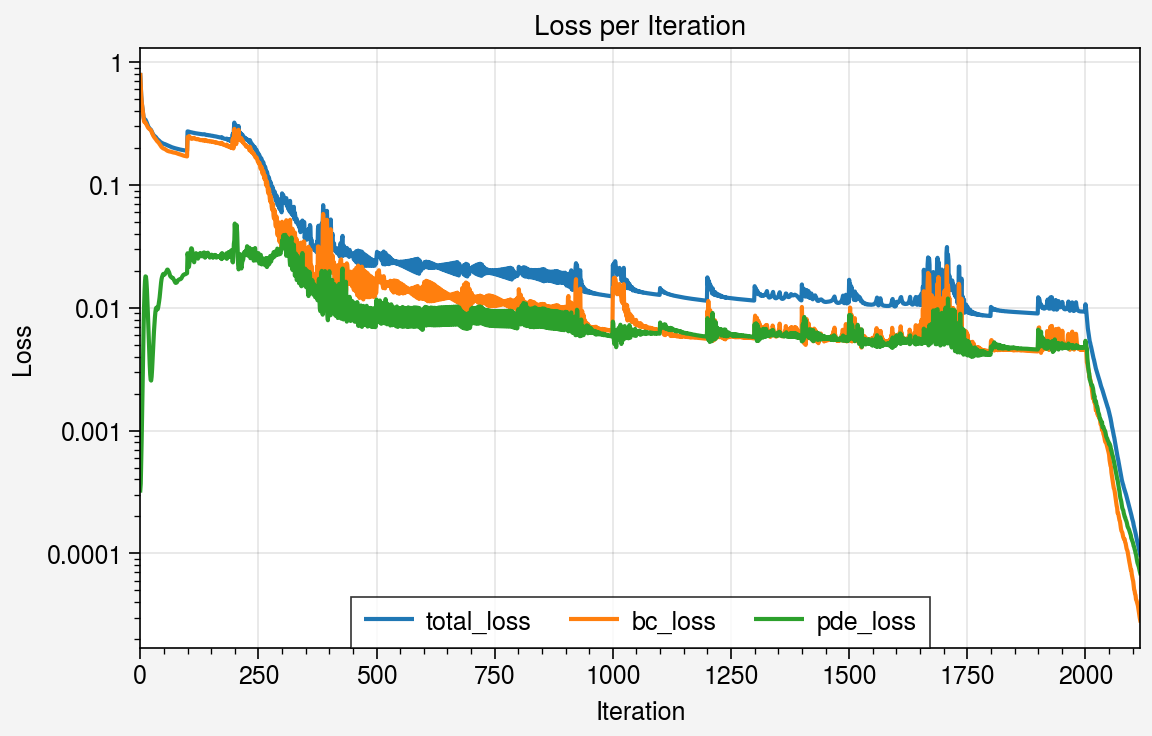

In [15]:
_ = area_eval.plot_loss_curve(log_scale=True)

### 4.4 Export data

In [16]:
# store the x,y,velocity_magnitude data
x_data = area_eval.data_dict['x']
y_data = area_eval.data_dict['y']
u_data = area_eval.data_dict['u']

#save as txt file
import numpy as np
array = np.column_stack((x_data, y_data, u_data))
np.savetxt('outlet_velocity.txt', array)

## 5. Optional FEM reference comparison

With NGSolve installed, compare the best model from the fixed-sample LBFGS phase.

In [17]:
try:
    import ngsolve  # noqa: F401
except (ImportError, OSError) as exc:
    print(f'Skipping optional FEM comparison: {exc}')
else:
    import numpy as np

    fem_reference = domain.solve_fem(
        mesh_size=0.2,
        boundary_resolution=32,
        max_iterations=20,
    )
    fem_area = fem_reference.area_list[0]
    fem_area.sampling_area([100, 40])
    fem_values = fem_area['u_ref']
    pinn_area = domain.area_list[0].evaluate(model2best)
    u_error = float(np.mean(np.abs(pinn_area.data_dict['u'] - fem_values)))
    if not np.isfinite(u_error):
        raise RuntimeError('FEM comparison produced a non-finite error')
    print(f'FEM mean absolute u error: {u_error:.6e}')

FEM mean absolute u error: 1.550522e+00
